In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Variaveis do problema
r0 = 0 # Estado inicial de recurso (estoque)
p = 45 # preço de venda por unidade
c = 30 # custo de produção por unidade
D = 60 # Demanda esperada
sig = 10 # Desvio padrão da demanda

T_max = 30 # Número máximo de iterações

In [3]:
# Função de transição
# r: recurso disponível
# x: quantidade adquirida
# w: demanda realizada
def T(r, x, w):
    return max(0, r + x - w)

# Função Objetivo
def C(r, x, w):
    return p * min(r+x, w) - c * x

# Simulação de demanda
import scipy.stats as stats
def simulate_demand(D, sig, T):
    return stats.norm.rvs(loc=D, scale=sig, size=T) # Demanda simulada, garantindo que seja não negativa

# Politica (adquirir ou não adquirir recursos)
# theta_max: quantidade máxima a produzir
# theta_min: quantidade mínima a produzir
def policy(r, theta_max, theta_min):
        if r < theta_min:
            return theta_max - r
        else:
            return 0

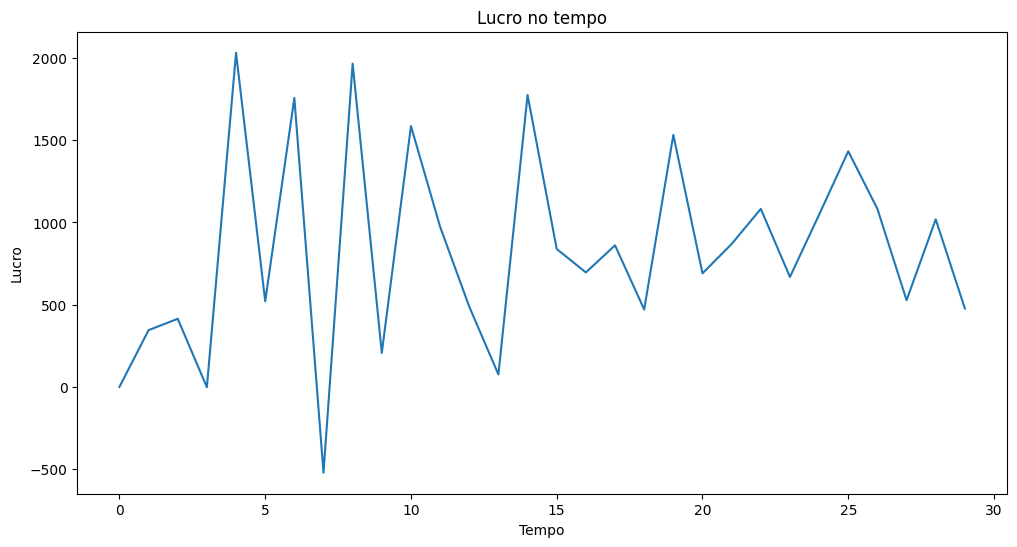

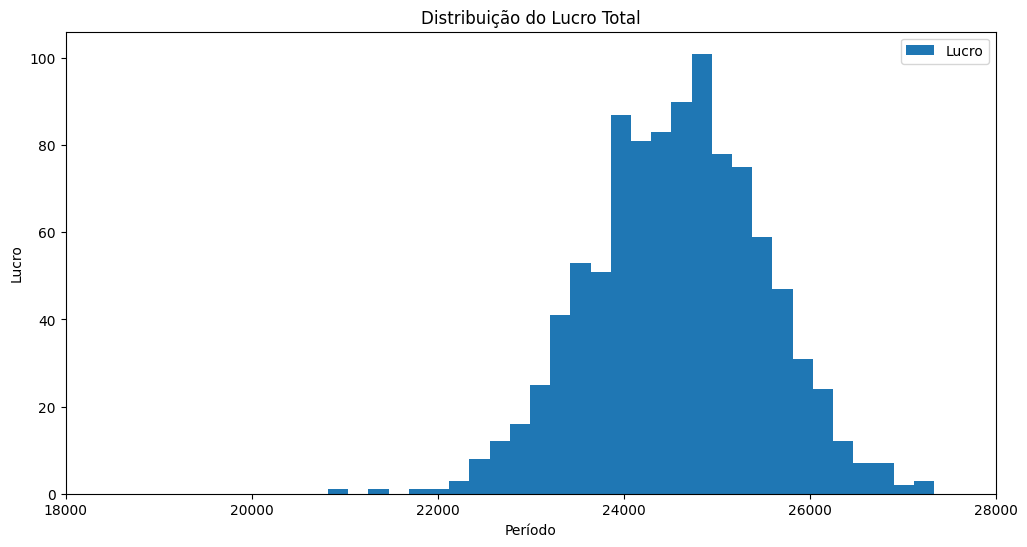

Média do Lucro Total: 24577.14
Desvio Padrão do Lucro Total: 923.45


In [4]:
#print("t r(t) w(t+1) profit(t) x(t)")
sums = []

N = 1000 # Número de simulações

for i in range(N):
    # Simulando o processo
    w = simulate_demand(D, sig, T_max) # Simula a demanda para o período t+1 (w[0] = w(1))
    r = [r0] # Lista para armazenar o recurso disponível em cada período
    profit = [] # Lista para armazenar o lucro em cada período
    for t in range(T_max):
        if t == 0:
            x = 0
        else:
            x = policy(r[t], 110, 80) # Decide a quantidade a produzir com base na política
        profit.append(C(r[t], x, w[t])) # Calcula o lucro para o período t
        r.append(T(r[t], x, w[t])) # Computa r(t+1)
        #print(t, round(r[t]), round(w[t]), round(profit[t],2), round(x))
    if i == N-1:
        plt.figure(figsize=(12, 6))
        plt.plot(profit)
        plt.title('Lucro no tempo')
        plt.xlabel('Tempo')
        plt.ylabel('Lucro')
        plt.show()
    sums.append(sum(profit))

# Plotando os resultados
plt.figure(figsize=(12, 6))
plt.hist(sums, bins=30, label='Lucro')
plt.title('Distribuição do Lucro Total')
plt.xlabel('Período')
plt.ylabel('Lucro')
plt.xlim(18000, 28000)
plt.legend()
plt.show()

# Calculando a média e o desvio padrão dos lucros totais
mean_profit = sum(sums) / len(sums)
std_profit = (sum((x - mean_profit) ** 2 for x in sums) / len(sums)) ** 0.5
print(f'Média do Lucro Total: {mean_profit:.2f}')
print(f'Desvio Padrão do Lucro Total: {std_profit:.2f}')


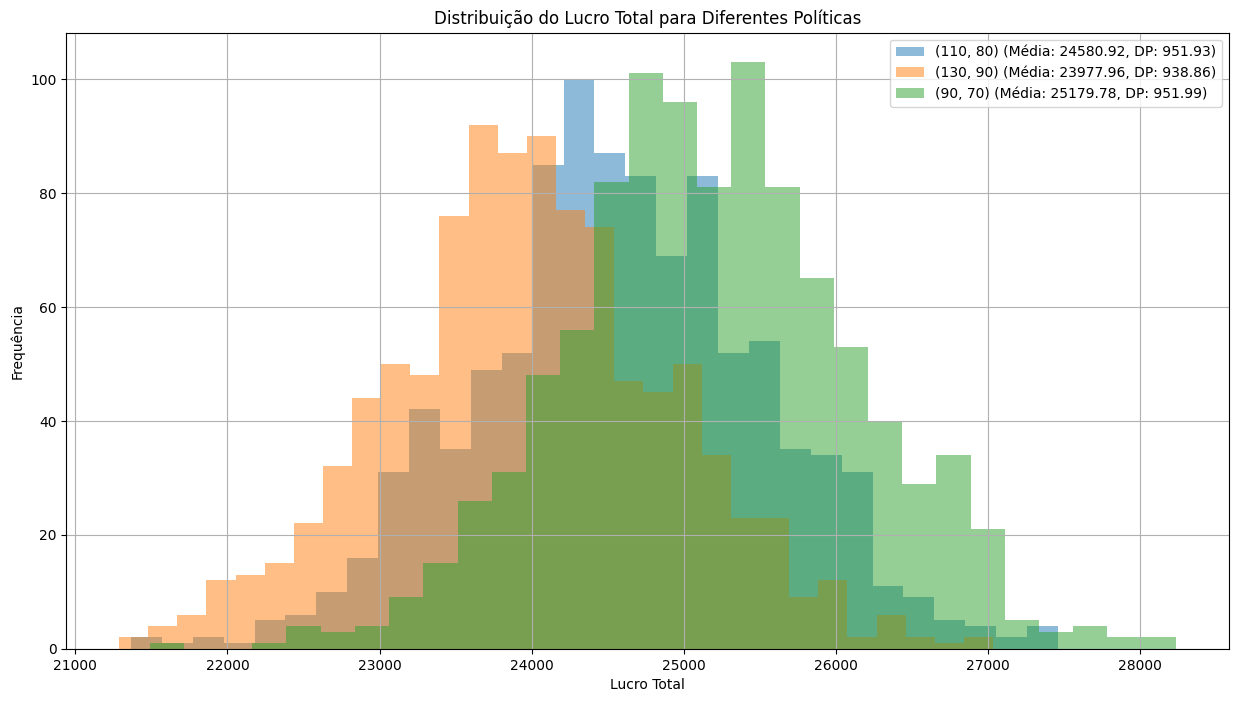

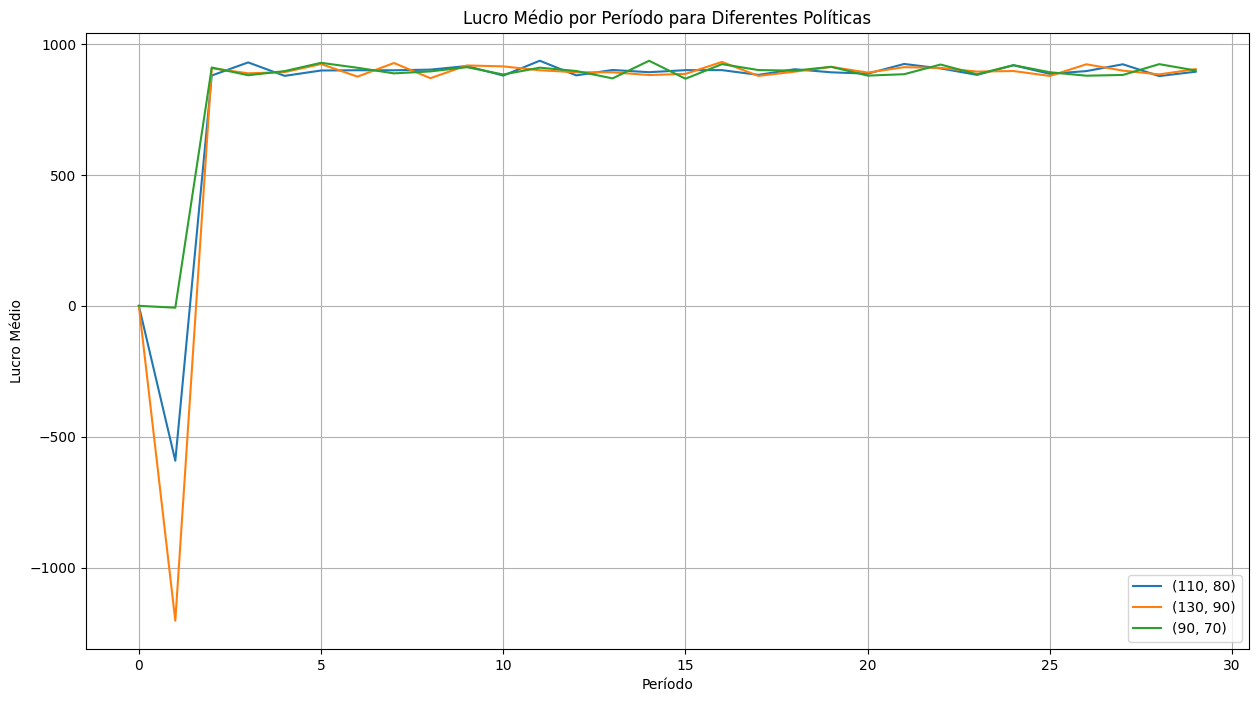


(110, 80):
  Média do Lucro Total: 24580.92
  Desvio Padrão do Lucro Total: 951.93
----------------------------------------

(130, 90):
  Média do Lucro Total: 23977.96
  Desvio Padrão do Lucro Total: 938.86
----------------------------------------

(90, 70):
  Média do Lucro Total: 25179.78
  Desvio Padrão do Lucro Total: 951.99
----------------------------------------


In [15]:
def run_simulation(theta_max, theta_min, N_simulations, T_max, r0, D_mean, sig_std_dev, C_func, T_func, simulate_demand_func, policy_func):
    all_total_profits = []
    # Inicializa um array para armazenar o lucro cumulativo em cada passo de tempo
    cumulative_profit_at_t = np.zeros(T_max)

    for i in range(N_simulations):
        w = simulate_demand_func(D_mean, sig_std_dev, T_max)
        r = [r0]
        profit_per_run = []
        for t in range(T_max):
            if t == 0:
                x = 0
            else:
                x = policy_func(r[t], theta_max, theta_min) # Decide a quantidade a produzir com base na política
            current_profit = C_func(r[t], x, w[t]) # Calcula o lucro para o período t
            profit_per_run.append(current_profit)
            # Adiciona o lucro atual à soma cumulativa para este passo de tempo
            cumulative_profit_at_t[t] += current_profit
            r.append(T_func(r[t], x, w[t])) # Computa r(t+1)
        all_total_profits.append(sum(profit_per_run))

    # Calcula o lucro médio por passo de tempo
    average_profit_per_time_step = cumulative_profit_at_t / N_simulations
    return all_total_profits, average_profit_per_time_step


policies = {
    '(110, 80)': (110, 80),
    '(130, 90)': (130, 90),
    '(90, 70)': (90, 70)
}

N = 1000 # Número de simulações

results = {}

# Executar simulação para cada política
for name, (theta_max, theta_min) in policies.items():
    # Chame a função de simulação com os parâmetros de política atuais
    sums, avg_profit_over_time = run_simulation(theta_max, theta_min, N, T_max, r0, D, sig, C, T, simulate_demand, policy)
    results[name] = {
        'sums': sums,
        'mean_profit': np.mean(sums),
        'std_profit': np.std(sums),
        'avg_profit_over_time': avg_profit_over_time # Armazena o lucro médio ao longo do tempo
    }

# Plotando os resultados da distribuição do lucro total
plt.figure(figsize=(15, 8))
for name, data in results.items():
    plt.hist(data['sums'], bins=30, alpha=0.5, label=f'{name} (Média: {data["mean_profit"]:.2f}, DP: {data["std_profit"]:.2f})')

plt.title('Distribuição do Lucro Total para Diferentes Políticas')
plt.xlabel('Lucro Total')
plt.ylabel('Frequência')
plt.legend()
plt.grid(True)
plt.show()

# Plotando o lucro médio por período para diferentes políticas
plt.figure(figsize=(15, 8))
for name, data in results.items():
    plt.plot(data['avg_profit_over_time'], label=f'{name}')

plt.title('Lucro Médio por Período para Diferentes Políticas')
plt.xlabel('Período')
plt.ylabel('Lucro Médio')
plt.legend()
plt.grid(True)
plt.show()

for name, data in results.items():
    print(f"\n{name}:")
    print(f"  Média do Lucro Total: {data['mean_profit']:.2f}")
    print(f"  Desvio Padrão do Lucro Total: {data['std_profit']:.2f}")
    print("-" * 40)
